# 프로젝트 중간보고 | NeuroStat

## 1. 프로젝트 개요

본 프로젝트는 EEG 시계열 데이터에서 통계적 특징을 추출하고, 비지도 학습을 활용하여 데이터의 잠재 구조를 분석하고 이상 패턴을 탐지하는 것을 목표로 함.

## 2. 중간 결과

### 2.1 데이터 처리 및 피처 엔지니어링

- 총 약 17,300개의 EEG parquet 샘플 처리

- 각 파일은 (10000 × 20) 시계열 데이터로 구성

- 채널별 통계 특징 추출 (mean, std, min, max, skew, kurtosis 등)

✓ autocorr(주기성/반복성 파악) 배제. 계산이 무겁고 다른 피쳐만으로도 표현 가능

- 최종 feature matrix 구성 (약 200개 → autocorr 배제 후 180개 feature)

### 차원 축소 및 구조 분석

- PCA 수행 결과:

2차원 기준 약 45% 설명력 | 3차원 기준 약 55% 설명력

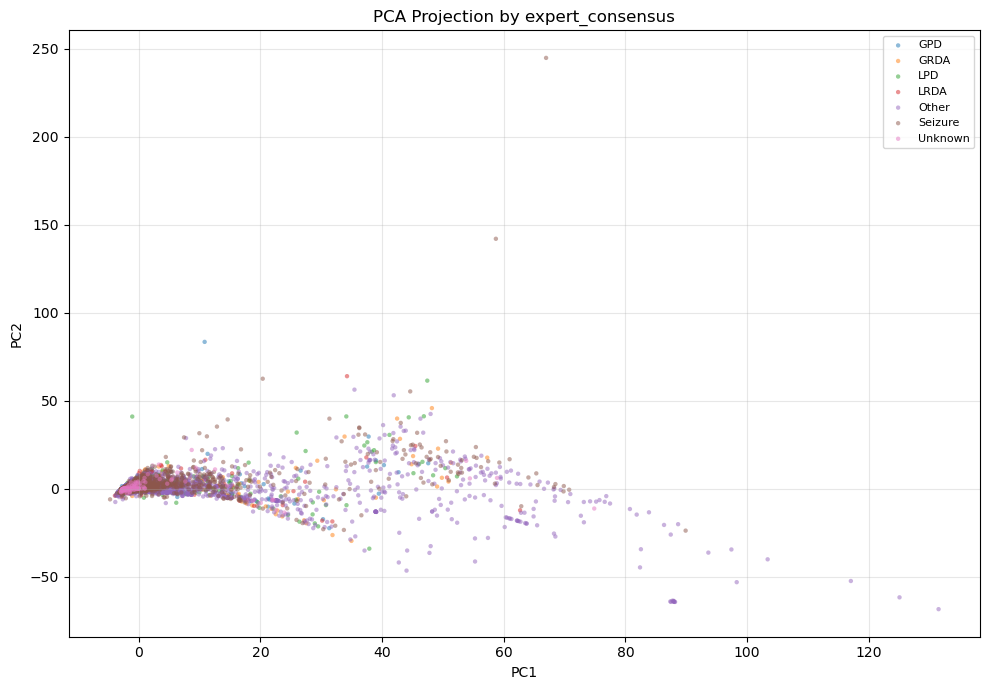

- Insight:

PCA 결과, EEG 데이터는 저차원 공간에서도 일정 수준의 분산이 유지되며 완전히 압축되기 어려운 고차원적 특성을 보임. 또한 데이터는 뚜렷하게 분리된 군집 형태라기보다, 연속적인 분포 구조를 가지며 클래스 간 경계가 명확하지 않음을 확인함. 이는 EEG 신호가 시간적·공간적 변동성이 큰 연속 신호라는 특성을 반영하며, 단순한 선형 차원 축소만으로는 구조를 완전히 설명하기 어려움을 시사함.

따라서 이후 분석에서는

✓ 비선형 모델 활용 (예: tree-based, neural networks)

✓ 추가적인 feature engineering

두 방법을 통해 데이터의 복잡한 패턴을 보완적으로 학습할 필요가 있음.

### 2.3 클러스터링 결과

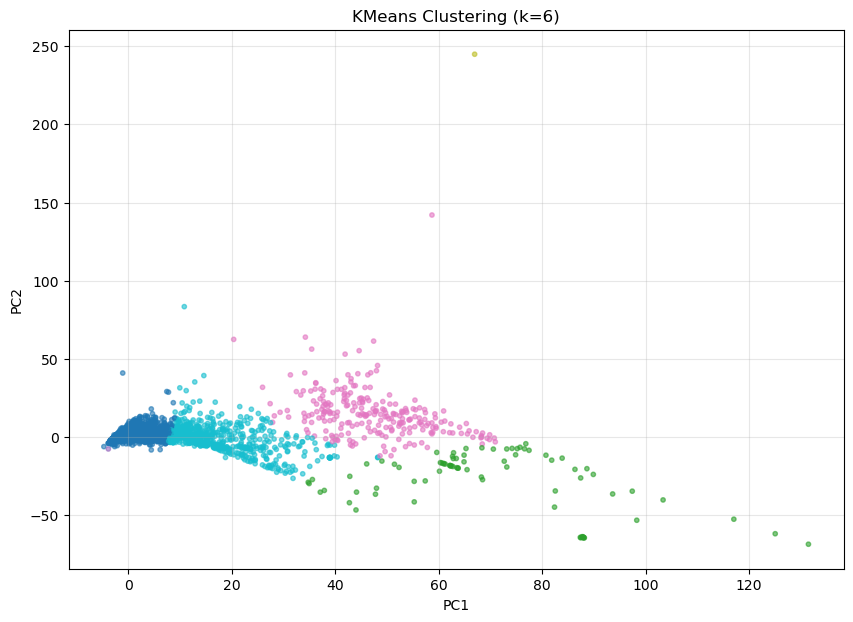

- K-means 적용

- silhouette score ≈ 0.77 

Insight:

feature 공간에서는 군집이 형성되지만 라벨과 완전히 일치하지 않음. (라벨 불순도 높음)

→ EEG 패턴은 연속적이며 명확한 경계가 존재하지 않음을 시사

### 2.4 이상 탐지 결과

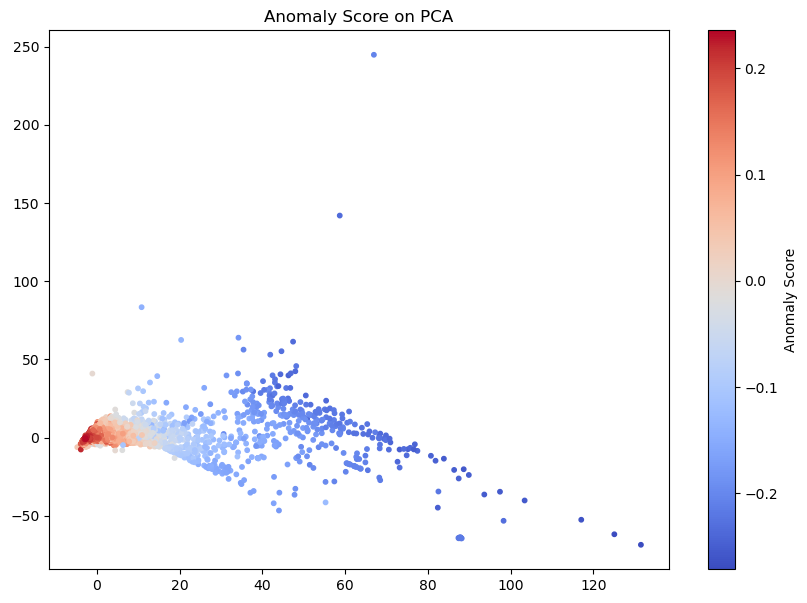

Isolation Forest 적용 (contamination=5%: 전체 데이터 중 상위 5%를 이상치로 간주하고 제거/분석)

초기 결과:

anomaly로 탐지된 데이터 대부분이 artifact. 센서 오류

문제:

비지도 학습이 실제 이상 신호가 아닌 데이터 오류를 우선적으로 탐지 (이상치 구간을 확인 결과)

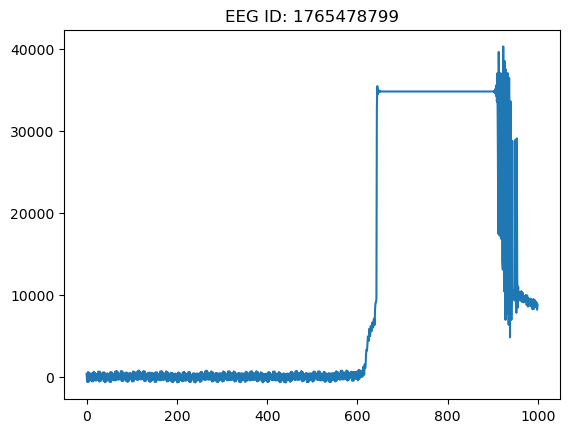

→ 서로 다른 환자들의 각 구간 그래프가 위처럼 튀는 것을 볼 수 있음

### 2.5 문제 해결 (데이터 정제)

다음 기준으로 **artifact** 제거:

- 비정상적으로 큰 amplitude(진폭) 제거

- 전체 분산이 큰 신호 제거

- NaN 비율 높은 데이터 제거

결과:

약 50% 데이터 제거 후 clean dataset 구성

### 2.6 개선된 결과

anomaly로 탐지된 EEG에서 주기성 있는 패턴 및 구조적 신호 확인

Insight:

모델이 단순 노이즈가 아닌 실제 EEG 패턴을 탐지하기 시작함

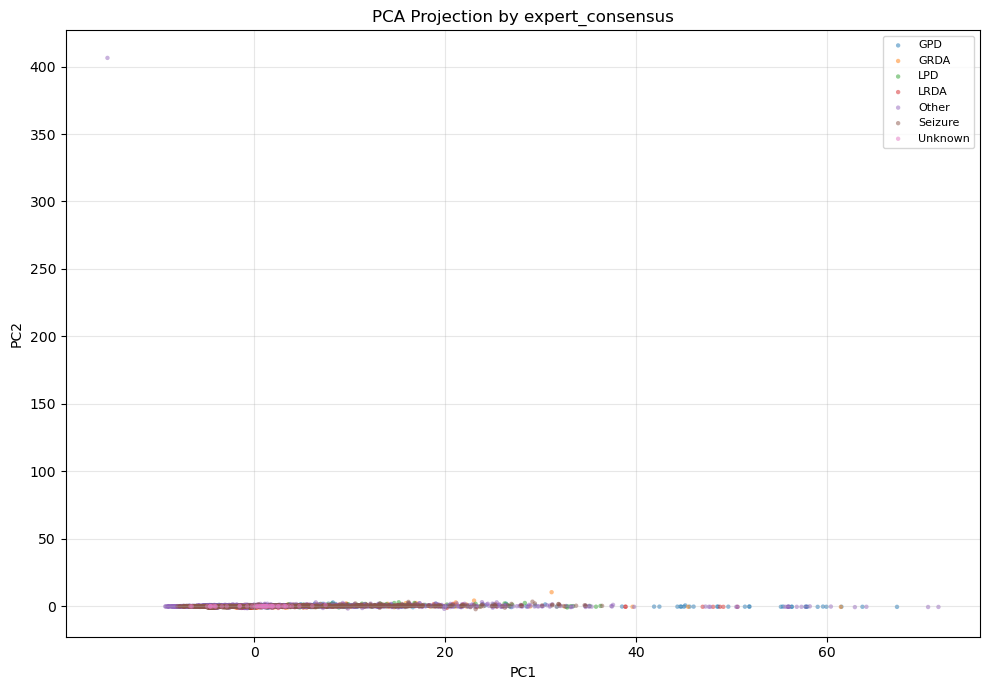

PCA

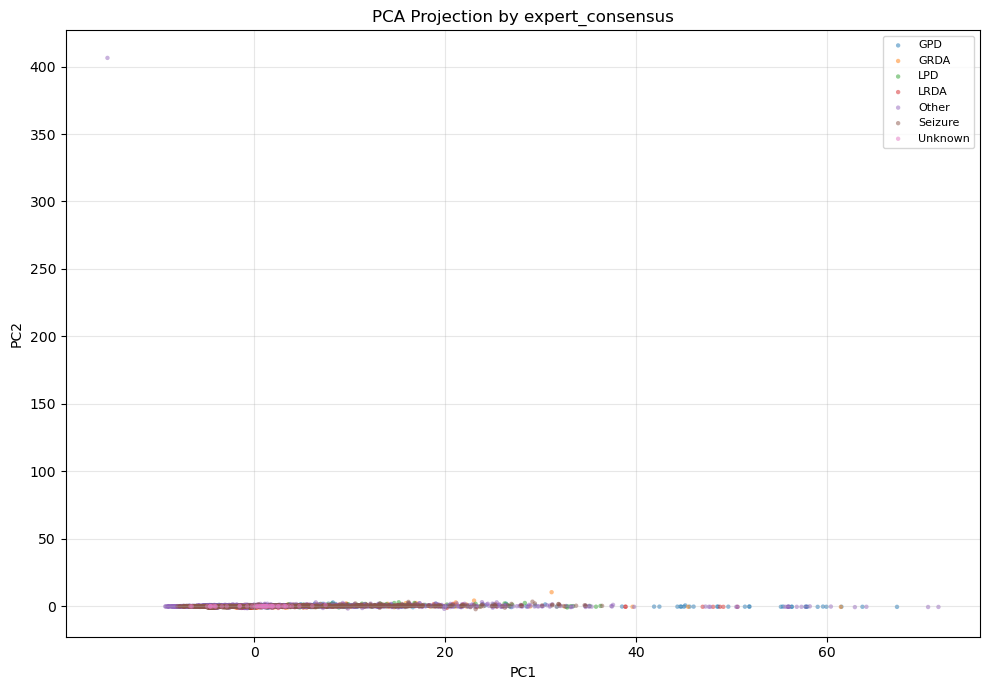

Isolation Forest

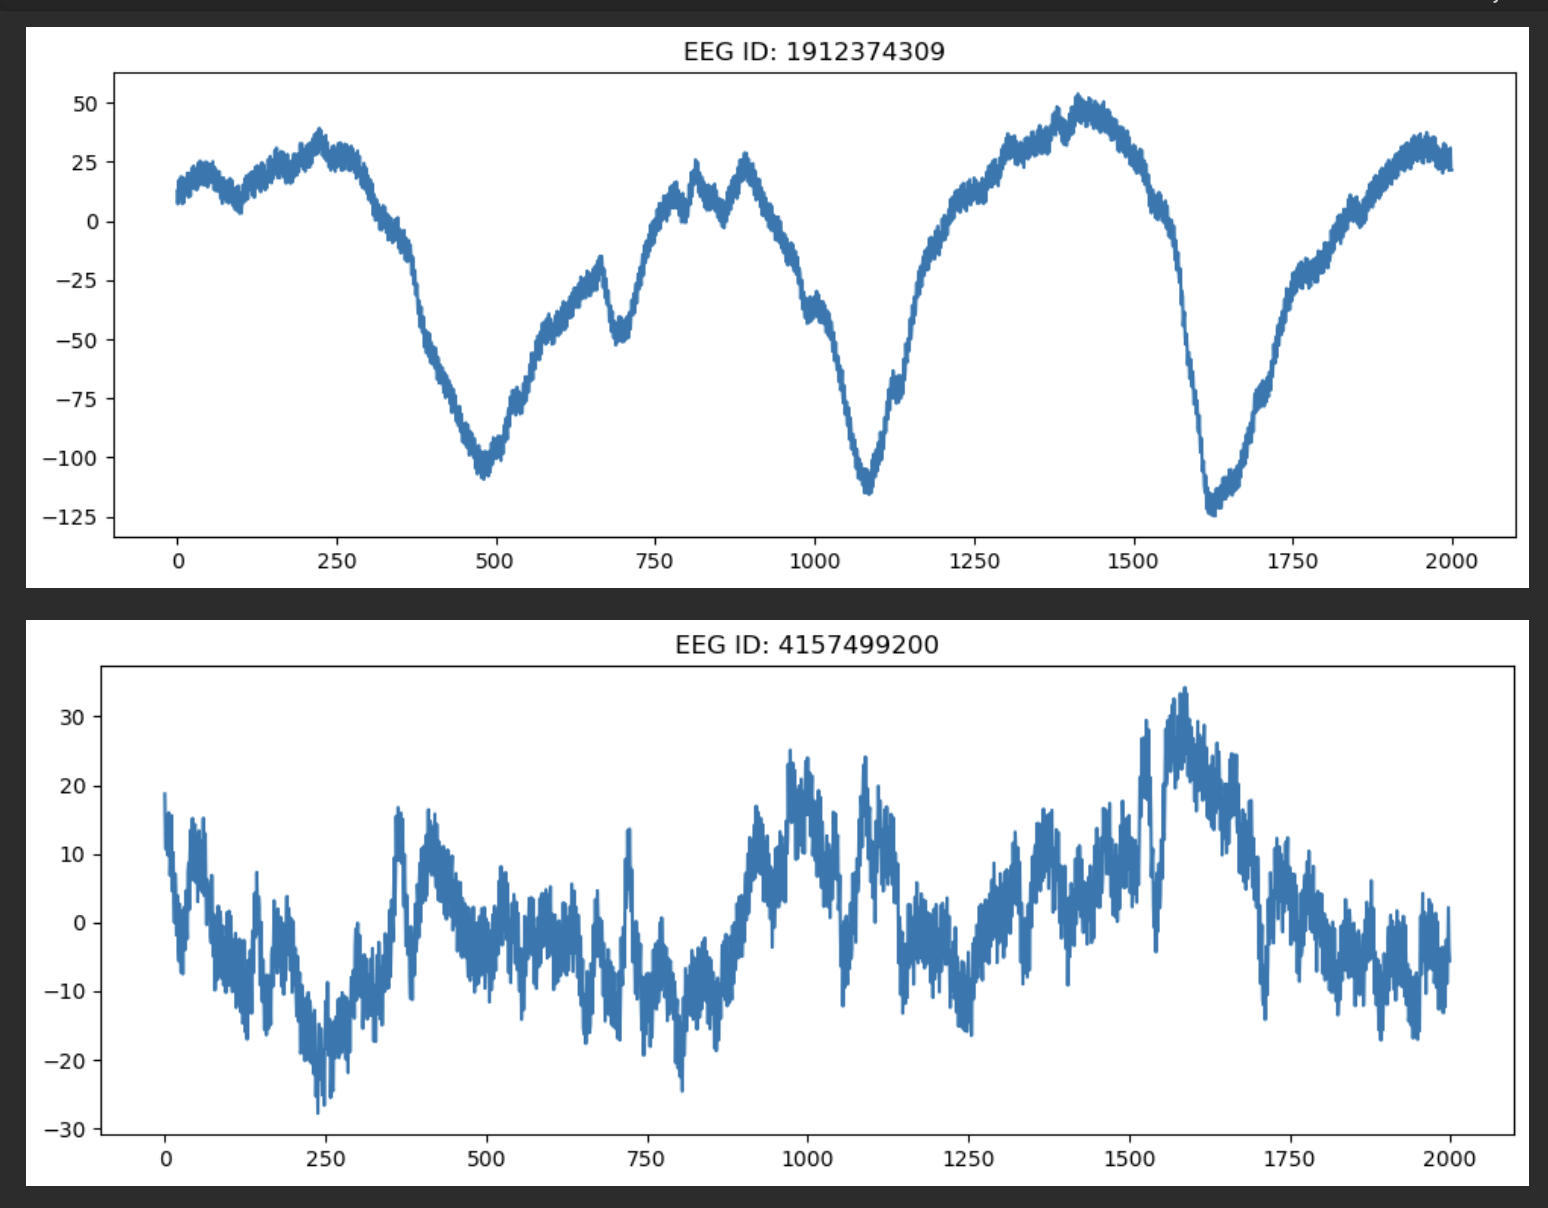

→ 서로 다른 환자들의 각 구간 그래프 주기성이 보임

## 3. 수정 목표

**초기 목표**

비지도 학습을 통해 EEG 이상 패턴 탐지

**수정된 목표**

artifact 제거를 포함한 신뢰 가능한 이상 탐지 시스템 구축. 단순 이상 탐지가 아닌 의미 있는 EEG 패턴 탐지

**수정 이유**

EEG 데이터는 노이즈 및 artifact가 많으며 이를 고려하지 않으면 모델이 의미 없는 결과를 생성함

## 4. 추후 일정

### 4.1 이상 신호 조기 감지 모델 설계 

- anomaly score 기반 위험도 정의

- 실시간 EEG 입력 시 이상 여부 판단 구조 설계

- threshold 기반 early warning 시스템 구축

### 4.2 최종 보고서 및 시각화

- PCA / anomaly / EEG 사례 시각화 정리

- 결과 해석 및 결론 정리

## 5. 현재 진행 상황 평가

✓ 전체 파이프라인 구축

✓ 주요 문제 (artifact) 해결 

✓ 의미 있는 패턴 탐지 단계 진입